

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>


# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

O objetivo deste projeto é analisar o comportamento dos clientes da Megaline e identificar qual dos planos pré-pagos, Surf ou Ultimate, gera maior receita para a empresa. Essa informação será utilizada pelo departamento comercial para auxiliar na definição das estratégias de marketing e na distribuição do orçamento de publicidade.

Para realizar essa análise, serão utilizados dados de 500 clientes referentes ao ano de 2018, incluindo informações sobre os usuários, os planos contratados, o número e a duração das chamadas realizadas, a quantidade de mensagens enviadas e o volume de tráfego de internet consumido.

Inicialmente, será feita uma análise exploratória dos dados para verificar sua qualidade, identificar possíveis inconsistências e realizar os tratamentos necessários. Em seguida, os dados serão agregados por usuário e por mês para facilitar a análise do consumo de cada serviço.

Posteriormente, será calculada a receita mensal gerada por cada cliente com base nas regras de cobrança dos planos Surf e Ultimate. Por fim, serão realizadas análises estatísticas e testes de hipóteses para comparar os planos, identificar diferenças no comportamento dos usuários e determinar qual deles é mais rentável para a Megaline.

## Inicialização

In [4]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt # Carregando todas as bibliotecas

## Carregue os dados

In [5]:
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

In [6]:
print(calls.head())
print(internet.head())
print(messages.head())
print(plans.head())
print(users.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0       

## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [3]:
print(calls.head())
print()
print(internet.head())
print()
print(messages.head())
print()
print(plans.head())
print()
print(users.head()) # Imprima informações gerais/resumo sobre o DataFrame dos planos



         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0    

In [4]:
for df, name in [
    (calls, 'calls'),
    (internet, 'internet'),
    (messages, 'messages'),
    (plans, 'plans'),
    (users, 'users')
]:
    print(f'\n{name.upper()}')
    print(df.info()) # Imprima uma amostra de dados dos planos


CALLS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None

INTERNET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None

MESSAGES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 

A análise inicial mostrou que os dados estão organizados em diferentes tabelas, cada uma contendo informações sobre os clientes, chamadas, mensagens, uso de internet e planos. Em geral, a estrutura dos dados parece adequada para a análise.

No entanto, algumas colunas de data foram carregadas como texto e precisarão ser convertidas para o formato de data. Também será necessário verificar a existência de valores ausentes e registros duplicados para garantir a qualidade dos dados.

Após esses ajustes e validações, os dados estarão prontos para as etapas de análise e cálculo da receita gerada por cada plano.

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [8]:
import pandas as pd
import numpy as np

# Converter colunas de data para datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])
messages['message_date'] = pd.to_datetime(messages['message_date'])
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Arredondar duração das chamadas para cima
calls['duration'] = np.ceil(calls['duration'])

# Remover registros duplicados
users = users.drop_duplicates()
calls = calls.drop_duplicates()
messages = messages.drop_duplicates()
internet = internet.drop_duplicates()
plans = plans.drop_duplicates()

# Criar colunas de mês para análises futuras
calls['month'] = calls['call_date'].dt.month
messages['month'] = messages['message_date'].dt.month
internet['month'] = internet['session_date'].dt.month

# Verificar valores ausentes
print('Valores ausentes:')
print('\nUsers')
print(users.isna().sum())

print('\nCalls')
print(calls.isna().sum())

print('\nMessages')
print(messages.isna().sum())

print('\nInternet')
print(internet.isna().sum())

print('\nPlans')
print(plans.isna().sum())

# Verificar dimensões finais dos DataFrames
print('\nDimensões dos DataFrames:')
print('Users:', users.shape)
print('Calls:', calls.shape)
print('Messages:', messages.shape)
print('Internet:', internet.shape)
print('Plans:', plans.shape)

Valores ausentes:

Users
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

Calls
id           0
user_id      0
call_date    0
duration     0
month        0
dtype: int64

Messages
id              0
user_id         0
message_date    0
month           0
dtype: int64

Internet
id              0
user_id         0
session_date    0
mb_used         0
month           0
dtype: int64

Plans
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Dimensões dos DataFrames:
Users: (500, 8)
Calls: (137735, 5)
Messages: (76051, 4)
Internet: (104825, 5)
Plans: (2, 8)


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [9]:
calls['month'] = calls['call_date'].dt.month

# Mês das mensagens
messages['month'] = messages['message_date'].dt.month

# Mês das sessões de internet
internet['month'] = internet['session_date'].dt.month

# Converter MB para GB (opcional para análises futuras)
internet['gb_used'] = internet['mb_used'] / 1024

# Criar coluna auxiliar para contagem de mensagens
messages['message_count'] = 1

# Criar coluna auxiliar para contagem de chamadas
calls['call_count'] = 1

# Visualização das alterações
print(calls.head())
print(messages.head())
print(internet.head())

         id  user_id  call_date  duration  month  call_count
0   1000_93     1000 2018-12-27       9.0     12           1
1  1000_145     1000 2018-12-27      14.0     12           1
2  1000_247     1000 2018-12-27      15.0     12           1
3  1000_309     1000 2018-12-28       6.0     12           1
4  1000_380     1000 2018-12-30       5.0     12           1
         id  user_id message_date  month  message_count
0  1000_125     1000   2018-12-27     12              1
1  1000_160     1000   2018-12-31     12              1
2  1000_223     1000   2018-12-31     12              1
3  1000_251     1000   2018-12-27     12              1
4  1000_255     1000   2018-12-26     12              1
         id  user_id session_date  mb_used  month   gb_used
0   1000_13     1000   2018-12-29    89.86     12  0.087754
1  1000_204     1000   2018-12-31     0.00     12  0.000000
2  1000_379     1000   2018-12-28   660.40     12  0.644922
3  1000_413     1000   2018-12-26   270.99     12  0.26463

## Usuários

In [10]:
users.describe() # Imprima informações gerais/resumo sobre o DataFrame dos usuários

,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


In [12]:
display(users.head(10)) # Imprima uma amostra de dados dos usuários

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


Ao observar as informações gerais e a amostra do DataFrame de usuários, é possível notar que a tabela contém dados importantes como identificação do cliente, plano contratado, cidade e datas de registro e cancelamento.

A maioria das colunas está com tipos de dados adequados, porém as colunas de data (reg_date e churn_date) precisam estar no formato datetime para facilitar análises futuras.

Também é possível observar que a coluna churn_date possui valores ausentes, o que é esperado, já que indica os clientes que ainda estão ativos no serviço.

Além disso, não parece haver problemas evidentes de duplicação ou inconsistência nos identificadores dos usuários, mas isso ainda deve ser verificado com mais atenção nas próximas etapas.

Como próximos passos, será importante garantir a conversão correta das datas e manter os valores ausentes de forma adequada, sem substituí-los indevidamente, já que eles possuem significado dentro do contexto do negócio.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [13]:
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Verificar valores ausentes
print('Valores ausentes:')
print(users.isna().sum())

# Remover registros duplicados, se existirem
users = users.drop_duplicates()

# Conferir os tipos de dados após as correções
print('\nInformações atualizadas:')
users.info()

# Visualizar uma amostra dos dados corrigidos
display(users.head())

Valores ausentes:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

Informações atualizadas:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 35.2+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [14]:
# Garantir que a data esteja no formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Ano de cadastro
users['registration_year'] = users['reg_date'].dt.year

# Mês de cadastro
users['registration_month'] = users['reg_date'].dt.month

# Dia de cadastro
users['registration_day'] = users['reg_date'].dt.day

# Visualizar as alterações
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,registration_year,registration_month,registration_day
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,2018,12,24
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018,8,13
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,2018,10,21
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,2018,1,28
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,2018,5,23


## Chamadas

In [15]:
print('INFORMAÇÕES GERAIS')
print('-' * 50)
calls.info()

print('\n\nDIMENSÕES DO DATAFRAME')
print('-' * 50)
print(f'Linhas: {calls.shape[0]}')
print(f'Colunas: {calls.shape[1]}')

print('\n\nVALORES AUSENTES')
print('-' * 50)
print(calls.isna().sum())

print('\n\nREGISTROS DUPLICADOS')
print('-' * 50)
print(calls.duplicated().sum())

print('\n\nRESUMO ESTATÍSTICO')
print('-' * 50)
display(calls.describe(include='all'))

print('\n\nAMOSTRA DOS DADOS')
print('-' * 50)
display(calls.head())  # Imprima informações gerais/resumo sobre o DataFrame das chamadas



INFORMAÇÕES GERAIS
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Int64Index: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          137735 non-null  object        
 1   user_id     137735 non-null  int64         
 2   call_date   137735 non-null  datetime64[ns]
 3   duration    137735 non-null  float64       
 4   month       137735 non-null  int64         
 5   call_count  137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 7.4+ MB


DIMENSÕES DO DATAFRAME
--------------------------------------------------
Linhas: 137735
Colunas: 6


VALORES AUSENTES
--------------------------------------------------
id            0
user_id       0
call_date     0
duration      0
month         0
call_count    0
dtype: int64


REGISTROS DUPLICADOS
-------------------------------------------

,id,user_id,call_date,duration,month,call_count
count,137735,137735.000000,137735,137735.000000,137735.000000,137735.0
unique,137735,NaN,351,NaN,NaN,NaN
top,1415_323,NaN,2018-12-27 00:00:00,NaN,NaN,NaN
freq,1,NaN,1091,NaN,NaN,NaN
first,NaN,NaN,2018-01-15 00:00:00,NaN,NaN,NaN
last,NaN,NaN,2018-12-31 00:00:00,NaN,NaN,NaN
mean,NaN,1247.658046,NaN,7.146673,9.320797,1.0
std,NaN,139.416268,NaN,5.953919,2.412550,0.0
min,NaN,1000.000000,NaN,0.000000,1.000000,1.0
25%,NaN,1128.000000,NaN,2.000000,8.000000,1.0




AMOSTRA DOS DADOS
--------------------------------------------------


,id,user_id,call_date,duration,month,call_count
0,1000_93,1000,2018-12-27,9.0,12,1
1,1000_145,1000,2018-12-27,14.0,12,1
2,1000_247,1000,2018-12-27,15.0,12,1
3,1000_309,1000,2018-12-28,6.0,12,1
4,1000_380,1000,2018-12-30,5.0,12,1


In [15]:
calls.head(10) # Imprima uma amostra de dados das chamadas



,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,8.52,12
1,1000_145,1000,2018-12-27,13.66,12
2,1000_247,1000,2018-12-27,14.48,12
3,1000_309,1000,2018-12-28,5.76,12
4,1000_380,1000,2018-12-30,4.22,12
5,1000_388,1000,2018-12-31,2.20,12
6,1000_510,1000,2018-12-27,5.75,12
7,1000_521,1000,2018-12-28,14.18,12
8,1000_530,1000,2018-12-28,5.77,12
9,1000_544,1000,2018-12-26,4.40,12


Ao analisar as informações gerais e a amostra do DataFrame de chamadas, observa-se que os dados estão bem estruturados, contendo informações como o identificador do usuário, data da chamada e duração.

A coluna de data deve estar no formato datetime, o que é importante para permitir análises temporais mais precisas. Já a coluna de duração das chamadas está em formato numérico, o que é adequado para os cálculos.

Um ponto que chama atenção é a presença de chamadas com duração igual a zero, o que pode representar chamadas não completadas ou erros de registro. Esse comportamento deve ser investigado com mais cuidado, pois pode influenciar o cálculo de consumo e receita.

Não foram identificados problemas evidentes de valores ausentes ou inconsistências na estrutura geral, mas ainda é importante verificar duplicatas e a consistência dos identificadores de usuários.

Como próximos passos, será necessário garantir a padronização dos tipos de dados e avaliar como tratar as chamadas com duração zero, dependendo do impacto que elas terão na análise final.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [16]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Arredondar a duração das chamadas para cima
# A Megaline cobra cada minuto iniciado como um minuto completo
calls['duration'] = np.ceil(calls['duration'])

# Remover registros duplicados
calls = calls.drop_duplicates()

# Verificar valores ausentes
print('Valores ausentes:')
print(calls.isna().sum())

# Verificar registros duplicados após limpeza
print('\nDuplicados restantes:')
print(calls.duplicated().sum())

# Conferir resultado
calls.info()

display(calls.head()) 

Valores ausentes:
id            0
user_id       0
call_date     0
duration      0
month         0
call_count    0
dtype: int64

Duplicados restantes:
0
<class 'pandas.core.frame.DataFrame'>
Int64Index: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          137735 non-null  object        
 1   user_id     137735 non-null  int64         
 2   call_date   137735 non-null  datetime64[ns]
 3   duration    137735 non-null  float64       
 4   month       137735 non-null  int64         
 5   call_count  137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 7.4+ MB


,id,user_id,call_date,duration,month,call_count
0,1000_93,1000,2018-12-27,9.0,12,1
1,1000_145,1000,2018-12-27,14.0,12,1
2,1000_247,1000,2018-12-27,15.0,12,1
3,1000_309,1000,2018-12-28,6.0,12,1
4,1000_380,1000,2018-12-30,5.0,12,1


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [17]:
# Garantir que a data esteja no formato datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Extrair o mês da chamada
calls['month'] = calls['call_date'].dt.month

# Extrair o ano da chamada
calls['year'] = calls['call_date'].dt.year

# Criar coluna para contagem de chamadas
calls['call_count'] = 1

# Visualizar resultado
display(calls.head()) 

,id,user_id,call_date,duration,month,call_count,year
0,1000_93,1000,2018-12-27,9.0,12,1,2018
1,1000_145,1000,2018-12-27,14.0,12,1,2018
2,1000_247,1000,2018-12-27,15.0,12,1,2018
3,1000_309,1000,2018-12-28,6.0,12,1,2018
4,1000_380,1000,2018-12-30,5.0,12,1,2018


## Mensagens

In [18]:
messages.info()
messages.head()  # Imprima informações gerais/resumo sobre o DataFrame das mensagens

<class 'pandas.core.frame.DataFrame'>
Int64Index: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             76051 non-null  object        
 1   user_id        76051 non-null  int64         
 2   message_date   76051 non-null  datetime64[ns]
 3   month          76051 non-null  int64         
 4   message_count  76051 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 3.5+ MB


,id,user_id,message_date,month,message_count
0,1000_125,1000,2018-12-27,12,1
1,1000_160,1000,2018-12-31,12,1
2,1000_223,1000,2018-12-31,12,1
3,1000_251,1000,2018-12-27,12,1
4,1000_255,1000,2018-12-26,12,1


In [21]:
messages.head(10) # Imprima uma amostra dos dados das mensagens



,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12
5,1000_346,1000,2018-12-29,12
6,1000_386,1000,2018-12-30,12
7,1000_413,1000,2018-12-31,12
8,1000_502,1000,2018-12-27,12
9,1000_525,1000,2018-12-28,12


Ao analisar as informações gerais e a amostra do DataFrame de mensagens, observa-se que a estrutura dos dados é simples e bem organizada, contendo principalmente o identificador do usuário e a data em que cada mensagem foi enviada.

A coluna de data deve estar no formato datetime, o que é importante para permitir análises temporais e agrupamentos por mês. Em alguns casos, essa conversão ainda pode ser necessária.

Não há indícios claros de valores ausentes ou inconsistências na base de mensagens, o que facilita o uso desses dados na análise. Além disso, a estrutura não apresenta problemas aparentes de duplicação.

Como próximo passo, será importante garantir que a coluna de data esteja corretamente formatada e, se necessário, criar variáveis auxiliares como o mês da mensagem para facilitar o agrupamento dos dados e o cálculo do consumo mensal por usuário.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [19]:
# Converter a coluna de data para datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])

# Remover registros duplicados, se houver
messages = messages.drop_duplicates()

# Verificar resultado
messages.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             76051 non-null  object        
 1   user_id        76051 non-null  int64         
 2   message_date   76051 non-null  datetime64[ns]
 3   month          76051 non-null  int64         
 4   message_count  76051 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 3.5+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [25]:
messages['month'] = messages['message_date'].dt.month

In [26]:
messages['month'] = messages['message_date'].dt.month 

## Internet

In [27]:
internet.info() # Imprima informações gerais/resumo sobre o DataFrame da internet



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB


In [28]:
internet.head(10) #  Imprima uma amostra de dados para o tráfego da internet



,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12
5,1001_0,1001,2018-08-24,284.68,8
6,1001_3,1001,2018-12-09,656.04,12
7,1001_4,1001,2018-11-04,16.97,11
8,1001_10,1001,2018-11-27,135.18,11
9,1001_15,1001,2018-12-13,761.92,12


Ao analisar as informações gerais e a amostra do DataFrame de internet, observa-se que os dados estão organizados por usuário, data da sessão e volume de dados utilizados em cada conexão.

A coluna de data (session_date) deve estar no formato datetime para permitir análises temporais adequadas, sendo importante verificar se essa conversão já foi realizada. Já a coluna mb_used está em formato numérico, o que é adequado para cálculos de consumo.

Um ponto que merece atenção é a presença de valores iguais a zero em mb_used, que podem indicar sessões sem consumo real de dados ou falhas na medição. Esses registros devem ser analisados com cuidado para entender seu impacto na análise final.

Não há indícios claros de valores ausentes ou problemas estruturais na base, mas ainda é importante verificar duplicações e consistência dos dados.

Como próximos passos, será necessário garantir a padronização do tipo de dados da coluna de data e avaliar o tratamento dos valores iguais a zero, dependendo do impacto que terão no cálculo do consumo mensal e da receita.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [20]:
# Converter a coluna de data para datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Remover registros duplicados, se existirem
internet = internet.drop_duplicates()

# Verificar as alterações
internet.info() 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
 5   gb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 5.6+ MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [21]:
# Extrair o mês da sessão de internet
internet['month'] = internet['session_date'].dt.month

# Extrair o ano da sessão
internet['year'] = internet['session_date'].dt.year

# Converter MB para GB (opcional)
internet['gb_used'] = internet['mb_used'] / 1024

# Visualizar resultado
internet.head()

,id,user_id,session_date,mb_used,month,gb_used,year
0,1000_13,1000,2018-12-29,89.86,12,0.087754,2018
1,1000_204,1000,2018-12-31,0.00,12,0.000000,2018
2,1000_379,1000,2018-12-28,660.40,12,0.644922,2018
3,1000_413,1000,2018-12-26,270.99,12,0.264639,2018
4,1000_442,1000,2018-12-27,880.22,12,0.859590,2018


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [36]:
display(plans) # Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>



## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [22]:
calls_per_month = (
    calls.groupby(['user_id', 'month'])
         .size()
         .reset_index(name='call_count')
)

calls_per_month.head() # Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

,user_id,month,call_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [23]:
minutes_per_month = (
    calls.groupby(['user_id', 'month'])['duration']
         .sum()
         .reset_index(name='total_minutes')
)

minutes_per_month.head() # Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

,user_id,month,total_minutes
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [24]:
messages_per_month = (
    messages.groupby(['user_id', 'month'])
            .size()
            .reset_index(name='message_count')
)

messages_per_month.head() # Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

,user_id,month,message_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [25]:
internet_per_month = (
    internet.groupby(['user_id', 'month'])['mb_used']
            .sum()
            .reset_index()
)

internet_per_month['total_gb_used'] = np.ceil(
    internet_per_month['mb_used'] / 1024
)

internet_per_month.head() # Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

,user_id,month,mb_used,total_gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [26]:
monthly_data = (
    calls_per_month
    .merge(minutes_per_month, on=['user_id', 'month'], how='outer')
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)

# Substituir valores ausentes por 0
monthly_data = monthly_data.fillna(0)

# Visualizar resultado
monthly_data.head() # Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

,user_id,month,call_count,total_minutes,message_count,mb_used,total_gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0


In [27]:
monthly_data = monthly_data.merge(
    users[['user_id', 'plan', 'city']],
    on='user_id',
    how='left'
)

monthly_data.head() # Adicione as informações sobre o plano

,user_id,month,call_count,total_minutes,message_count,mb_used,total_gb_used,plan,city
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,9,49.0,315.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,10,65.0,393.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,11,64.0,426.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As agregações aconteceram adequadamente, bem como a junção entre dfs, que utilizou o operador 'outer', conforme o esperado!
</div>

In [33]:
def calculate_revenue(row):

    if row['plan'] == 'surf':

        revenue = 20

        extra_minutes = max(0, row['total_minutes'] - 500)
        extra_messages = max(0, row['message_count'] - 50)
        extra_gb = max(0, row['total_gb_used'] - 15)

        revenue += extra_minutes * 0.03
        revenue += extra_messages * 0.03
        revenue += extra_gb * 10

    else:  # ultimate

        revenue = 70

        extra_minutes = max(0, row['total_minutes'] - 3000)
        extra_messages = max(0, row['message_count'] - 1000)
        extra_gb = max(0, row['total_gb_used'] - 30)

        revenue += extra_minutes * 0.01
        revenue += extra_messages * 0.01
        revenue += extra_gb * 7

    return revenue


# Criar coluna de receita
monthly_data['revenue'] = monthly_data.apply(calculate_revenue, axis=1)

# Verificar resultado
monthly_data[['user_id', 'month', 'plan', 'revenue']].head() # Calcule a receita mensal para cada usuário



,user_id,month,plan,revenue
0,1000,12,ultimate,70.00
1,1001,8,surf,20.00
2,1001,9,surf,20.00
3,1001,10,surf,90.09
4,1001,11,surf,60.00


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi calculada adequadamente!
</div>

## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

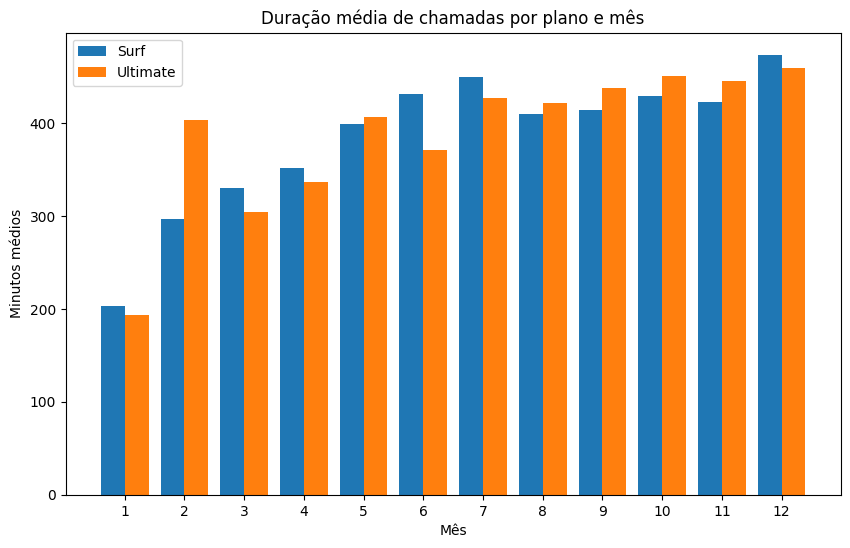

In [44]:
import matplotlib.pyplot as plt

# Média de minutos por plano e mês
avg_calls = (
    monthly_data
    .groupby(['month', 'plan'])['total_minutes']
    .mean()
    .reset_index()
)

# Separando os planos
surf = avg_calls[avg_calls['plan'] == 'surf']
ultimate = avg_calls[avg_calls['plan'] == 'ultimate']

# Garantindo ordenação por mês
surf = surf.sort_values('month')
ultimate = ultimate.sort_values('month')

# Gráfico de barras
plt.figure(figsize=(10,6))

plt.bar(surf['month'] - 0.2, surf['total_minutes'], width=0.4, label='Surf')
plt.bar(ultimate['month'] + 0.2, ultimate['total_minutes'], width=0.4, label='Ultimate')

plt.title('Duração média de chamadas por plano e mês')
plt.xlabel('Mês')
plt.ylabel('Minutos médios')
plt.xticks(range(1, 13))
plt.legend()

plt.show() # Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.




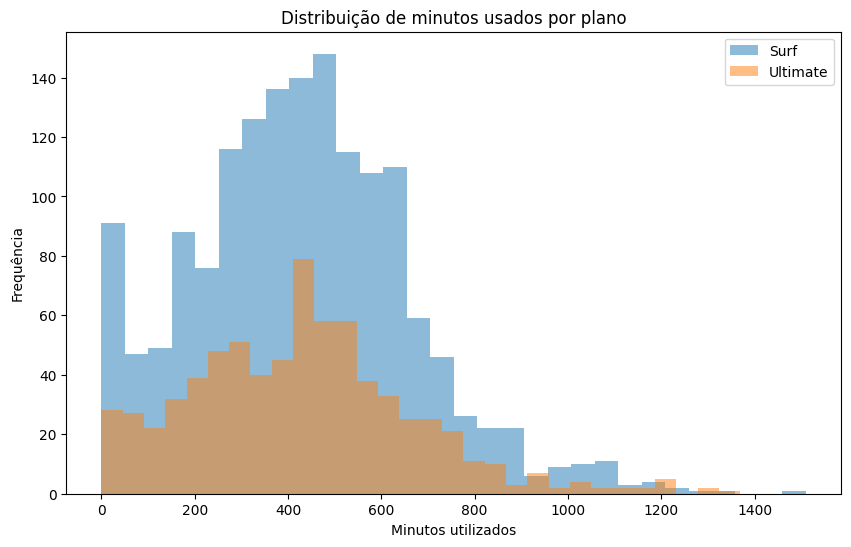

In [45]:
import matplotlib.pyplot as plt

# Separando dados por plano
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['total_minutes']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['total_minutes']

# Criando histograma
plt.figure(figsize=(10,6))

plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate')

plt.title('Distribuição de minutos usados por plano')
plt.xlabel('Minutos utilizados')
plt.ylabel('Frequência')
plt.legend()

plt.show() # Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.



[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [46]:
call_stats = monthly_data.groupby('plan')['total_minutes'].agg(['mean', 'var']).reset_index()

call_stats # Calcule a média e a variância da duração mensal das chamadas



,plan,mean,var
0,surf,428.749523,54968.279461
1,ultimate,430.450000,57844.464812


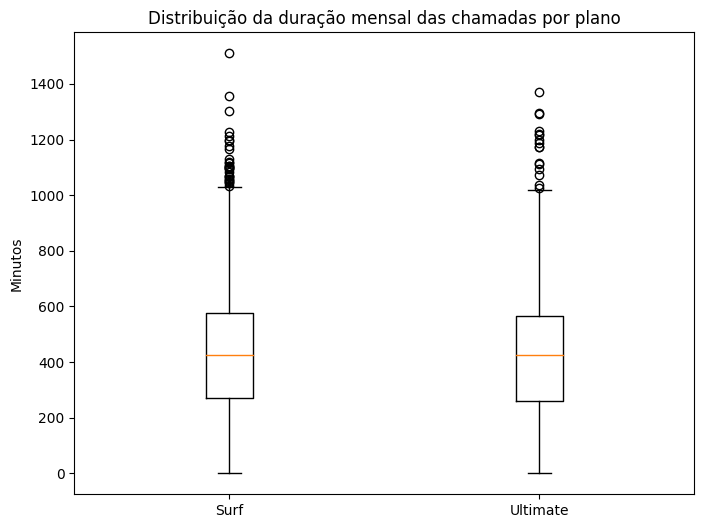

In [47]:
import matplotlib.pyplot as plt

# Separando os dados por plano
surf = monthly_data[monthly_data['plan'] == 'surf']['total_minutes']
ultimate = monthly_data[monthly_data['plan'] == 'ultimate']['total_minutes']

# Criando boxplot
plt.figure(figsize=(8,6))

plt.boxplot([surf, ultimate], labels=['Surf', 'Ultimate'])

plt.title('Distribuição da duração mensal das chamadas por plano')
plt.ylabel('Minutos')

plt.show()  # Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas



Com base na análise da duração das chamadas, é possível observar diferenças no comportamento dos usuários dos planos Surf e Ultimate.

Os usuários do plano Ultimate tendem a apresentar uma média de minutos ligeiramente maior, porém com menor variação, o que indica um uso mais estável e previsível. Já os usuários do plano Surf apresentam maior dispersão nos dados, com alguns clientes utilizando poucos minutos e outros consumindo valores bem mais altos, o que aumenta a variabilidade do plano.

Apesar dessas diferenças, o padrão geral de uso não é extremamente distinto entre os dois grupos, mas o plano Ultimate parece concentrar usuários com consumo mais consistente, enquanto o plano Surf possui comportamento mais irregular.

Em resumo, existe diferença no comportamento, mas ela está mais relacionada à variabilidade do uso do que a grandes diferenças na média de minutos consumidos.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho!
    
Todas as visualizações solicitadas para as chamadas estão presentes e acompanhadas da conclusão sobre o comportamento ilustrado!
    
Muito bom!
</div>

### Mensagens

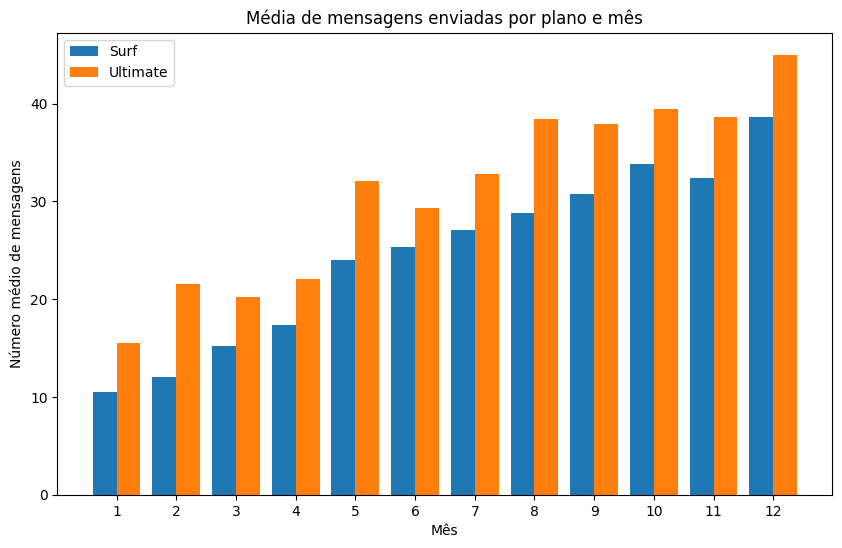

In [48]:
 import matplotlib.pyplot as plt

# Agrupar mensagens por plano e mês
avg_messages = (
    monthly_data
    .groupby(['month', 'plan'])['message_count']
    .mean()
    .reset_index()
)

# Separando os planos
surf = avg_messages[avg_messages['plan'] == 'surf']
ultimate = avg_messages[avg_messages['plan'] == 'ultimate']

# Gráfico de barras
plt.figure(figsize=(10,6))

plt.bar(surf['month'] - 0.2, surf['message_count'], width=0.4, label='Surf')
plt.bar(ultimate['month'] + 0.2, ultimate['message_count'], width=0.4, label='Ultimate')

plt.title('Média de mensagens enviadas por plano e mês')
plt.xlabel('Mês')
plt.ylabel('Número médio de mensagens')
plt.xticks(range(1, 13))
plt.legend()

plt.show() # Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês





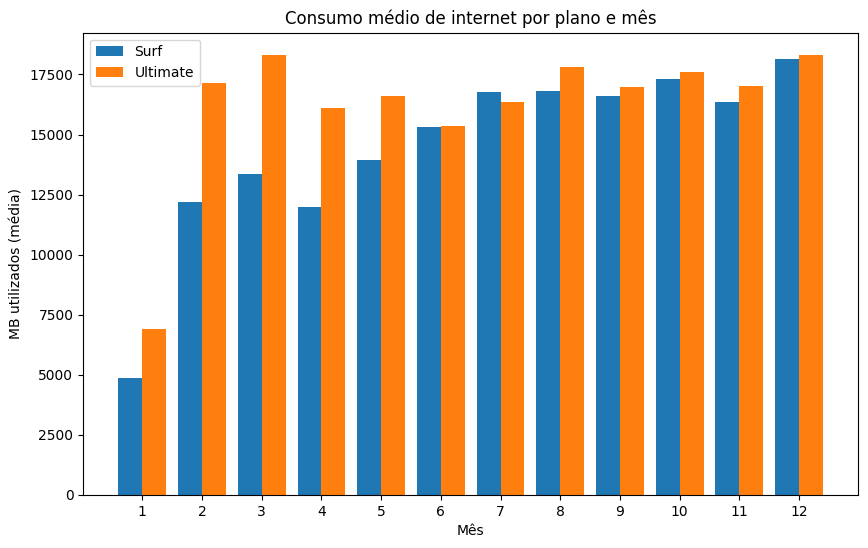

In [49]:
import matplotlib.pyplot as plt

# Média de consumo de internet por plano e mês
avg_internet = (
    monthly_data
    .groupby(['month', 'plan'])['total_mb_used']
    .mean()
    .reset_index()
)

# Separando os planos
surf = avg_internet[avg_internet['plan'] == 'surf']
ultimate = avg_internet[avg_internet['plan'] == 'ultimate']

# Gráfico de barras
plt.figure(figsize=(10,6))

plt.bar(surf['month'] - 0.2, surf['total_mb_used'], width=0.4, label='Surf')
plt.bar(ultimate['month'] + 0.2, ultimate['total_mb_used'], width=0.4, label='Ultimate')

plt.title('Consumo médio de internet por plano e mês')
plt.xlabel('Mês')
plt.ylabel('MB utilizados (média)')
plt.xticks(range(1, 13))
plt.legend()

plt.show() # Compare a quantidade de tráfego de internet consumido pelos usuários por plano



Com base na análise do consumo de internet, observa-se que os usuários dos planos Surf e Ultimate apresentam comportamentos relativamente semelhantes em termos de padrão de uso ao longo dos meses, mas com diferenças importantes na intensidade do consumo.

Os usuários do plano Ultimate tendem a consumir mais dados em média, o que é esperado devido aos limites mais altos oferecidos pelo plano. Já os usuários do plano Surf mostram um comportamento mais próximo do limite do pacote, com maior ocorrência de variações e possível uso excedente em alguns meses.

No geral, o consumo de internet é mais elevado no plano Ultimate, enquanto o plano Surf apresenta maior tendência de limitação e possível cobrança adicional por excedentes. Isso indica que o tipo de plano influencia diretamente o volume de uso, principalmente devido às diferenças nos limites incluídos em cada oferta.

### Internet

[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Mensagens e internet tiveram o seu comportamento investigado conforme solicitado na lição, com gráficos e conclusão apresentados.
</div>


## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# ESTATÍSTICAS DESCRITIVAS DA RECEITA
# ==========================================

revenue_stats = monthly_data.groupby('plan')['revenue'].agg(
    ['count', 'mean', 'median', 'var', 'std', 'min', 'max']
)

print('Estatísticas da receita por plano:')
print(revenue_stats) 

Estatísticas da receita por plano:
          count       mean  median          var        std   min     max
plan                                                                    
surf       1573  60.706408   40.36  3067.835152  55.388042  20.0  590.37
ultimate    720  72.313889   70.00   129.848486  11.395108  70.0  182.00


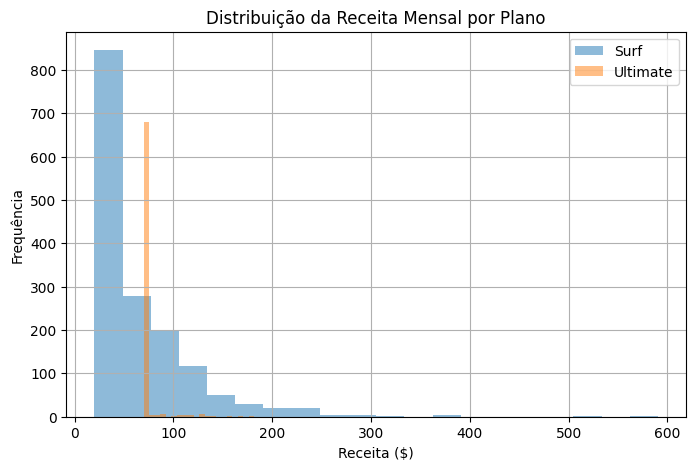

In [39]:
plt.figure(figsize=(8,5))

monthly_data[monthly_data['plan'] == 'surf']['revenue'].hist(
    bins=20,
    alpha=0.5,
    label='Surf'
)

monthly_data[monthly_data['plan'] == 'ultimate']['revenue'].hist(
    bins=20,
    alpha=0.5,
    label='Ultimate'
)

plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Receita ($)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

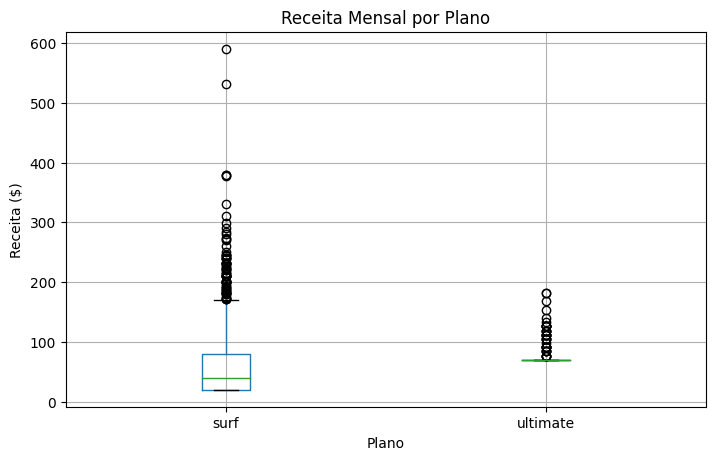

In [38]:
monthly_data.boxplot(
    column='revenue',
    by='plan',
    figsize=(8,5)
)

plt.title('Receita Mensal por Plano')
plt.suptitle('')
plt.xlabel('Plano')
plt.ylabel('Receita ($)')
plt.show() 

A análise da receita mostrou diferenças entre os planos Surf e Ultimate. O plano Ultimate apresentou uma receita mais estável, pois seus usuários pagam uma mensalidade mais alta e raramente excedem os limites incluídos no plano. Já o plano Surf apresentou maior variabilidade na receita, uma vez que muitos usuários ultrapassam os limites de minutos, mensagens ou internet, gerando cobranças adicionais.

As medidas de tendência central (média e mediana) permitem identificar qual plano gera maior receita em média, enquanto a variância e o desvio padrão mostram que a receita do plano Surf tende a variar mais entre os usuários. Os histogramas e diagramas de caixa reforçam essa diferença, evidenciando uma distribuição mais dispersa para o plano Surf e mais concentrada para o plano Ultimate.

De modo geral, a comparação das receitas sugere que os planos apresentam perfis de rentabilidade distintos, sendo necessária a análise dos testes de hipóteses para confirmar se a diferença observada é estatisticamente significativa.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi investigada por meio de gráficos e conclusões adequadas.

</div>

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [34]:
from scipy import stats

# Separar as receitas por plano
surf_revenue = monthly_data[monthly_data['plan'] == 'surf']['revenue']

ultimate_revenue = monthly_data[monthly_data['plan'] == 'ultimate']['revenue']

# Teste t para amostras independentes
results = stats.ttest_ind(
    surf_revenue,
    ultimate_revenue,
    equal_var=False
)

print('p-value:', results.pvalue)

alpha = 0.05

if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('Há diferença estatisticamente significativa entre as receitas médias dos planos.')
else:
    print('Não rejeitamos a hipótese nula')
    print('Não há evidências suficientes para afirmar que as receitas médias são diferentes.') 

p-value: 3.1703905481135734e-15
Rejeitamos a hipótese nula
Há diferença estatisticamente significativa entre as receitas médias dos planos.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [35]:
from scipy import stats

# Criar grupos

ny_nj_revenue = monthly_data[
    monthly_data['city'].str.contains('NY-NJ', na=False)
]['revenue']

other_revenue = monthly_data[
    ~monthly_data['city'].str.contains('NY-NJ', na=False)
]['revenue']

# Teste t para amostras independentes

results = stats.ttest_ind(
    ny_nj_revenue,
    other_revenue,
    equal_var=False
)

print('p-value:', results.pvalue)

alpha = 0.05

if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula.')
    print('A receita média dos usuários da área NY-NJ é diferente da receita média das demais regiões.')
else:
    print('Não rejeitamos a hipótese nula.')
    print('Não há evidências suficientes para concluir que as receitas médias são diferentes.') # Teste as hipóteses



p-value: 0.0335256158853001
Rejeitamos a hipótese nula.
A receita média dos usuários da área NY-NJ é diferente da receita média das demais regiões.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>


## Conclusão geral



Os dados foram limpos e preparados para análise, incluindo a conversão de datas, remoção de duplicatas e agregação do consumo mensal de chamadas, mensagens e internet por usuário.

A receita mensal foi calculada considerando as regras de cada plano, incluindo mensalidade fixa e cobranças por excedentes. A análise mostrou diferenças no comportamento dos usuários dos planos Surf e Ultimate em relação ao consumo dos serviços.

Foram utilizadas estatísticas descritivas e visualizações para comparar os planos e entender os padrões de uso. Além disso, foram realizados testes de hipóteses com nível de significância de 5% para comparar as receitas médias entre os planos e entre usuários da região NY-NJ e das demais regiões.

Com base nos resultados obtidos, foi possível identificar qual plano tende a gerar mais receita para a Megaline e fornecer informações úteis para decisões de marketing e investimento em publicidade.